# Plotting umaps.

## Prepare notebooks.

### Import Libraries.

In [1]:
import matplotlib.pyplot as plt
import scanpy as sc

### Constants.

In [2]:
H5AD_PATH = "../../../project_folder/data/gdrive/new_dataset/BloodPlus_celltype_pm_500k_filtered_.h5ad"
PROTOCOL_COLS = ["740-yp_[µm]", "mtg_[µm]", "rhflt3l_[ng_ml]", "gm-csf_[ng_ml]", "tpo_[ng_ml]", "sr1_[nm]", "um171_[nm]", "um729_[µm]", "scf_[ng_ml]", "butyzamide_[nm]", "retinoic_acid_[µm]", "ldl_[ng_ml]", "il3_[ng_ml]", "o2_[%]", "days_of_culture"]
# PROTOCOL_COLS = ["tpo_[ng_ml]", "um171_[nm]"]


## Data.

### Reading data to disk.

In [3]:
adata = sc.read_h5ad(H5AD_PATH)
adata

AnnData object with n_obs × n_vars = 471836 × 20
    obs: 'experiment_number', 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC-A :: FSC - Area', 'FSC-H :: FSC - Height', 'FSC-W :: FSC - Width', 'SSC-A :: SSC - Area', 'SSC-H :: SSC - Height', 'SSC-W :: SSC - Width', 'TIME', 'NA', 'AF Index', 'batch', '7-AAD', 'leiden', 'leiden_sub', 'leiden_old', 'cell_type'
    var: 'n', 'channel', 'marker', 'PnB', 'PnE', 'PnR', 'PnD', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'leiden_colors_old',

## Plots.

### Plotting over each channel.

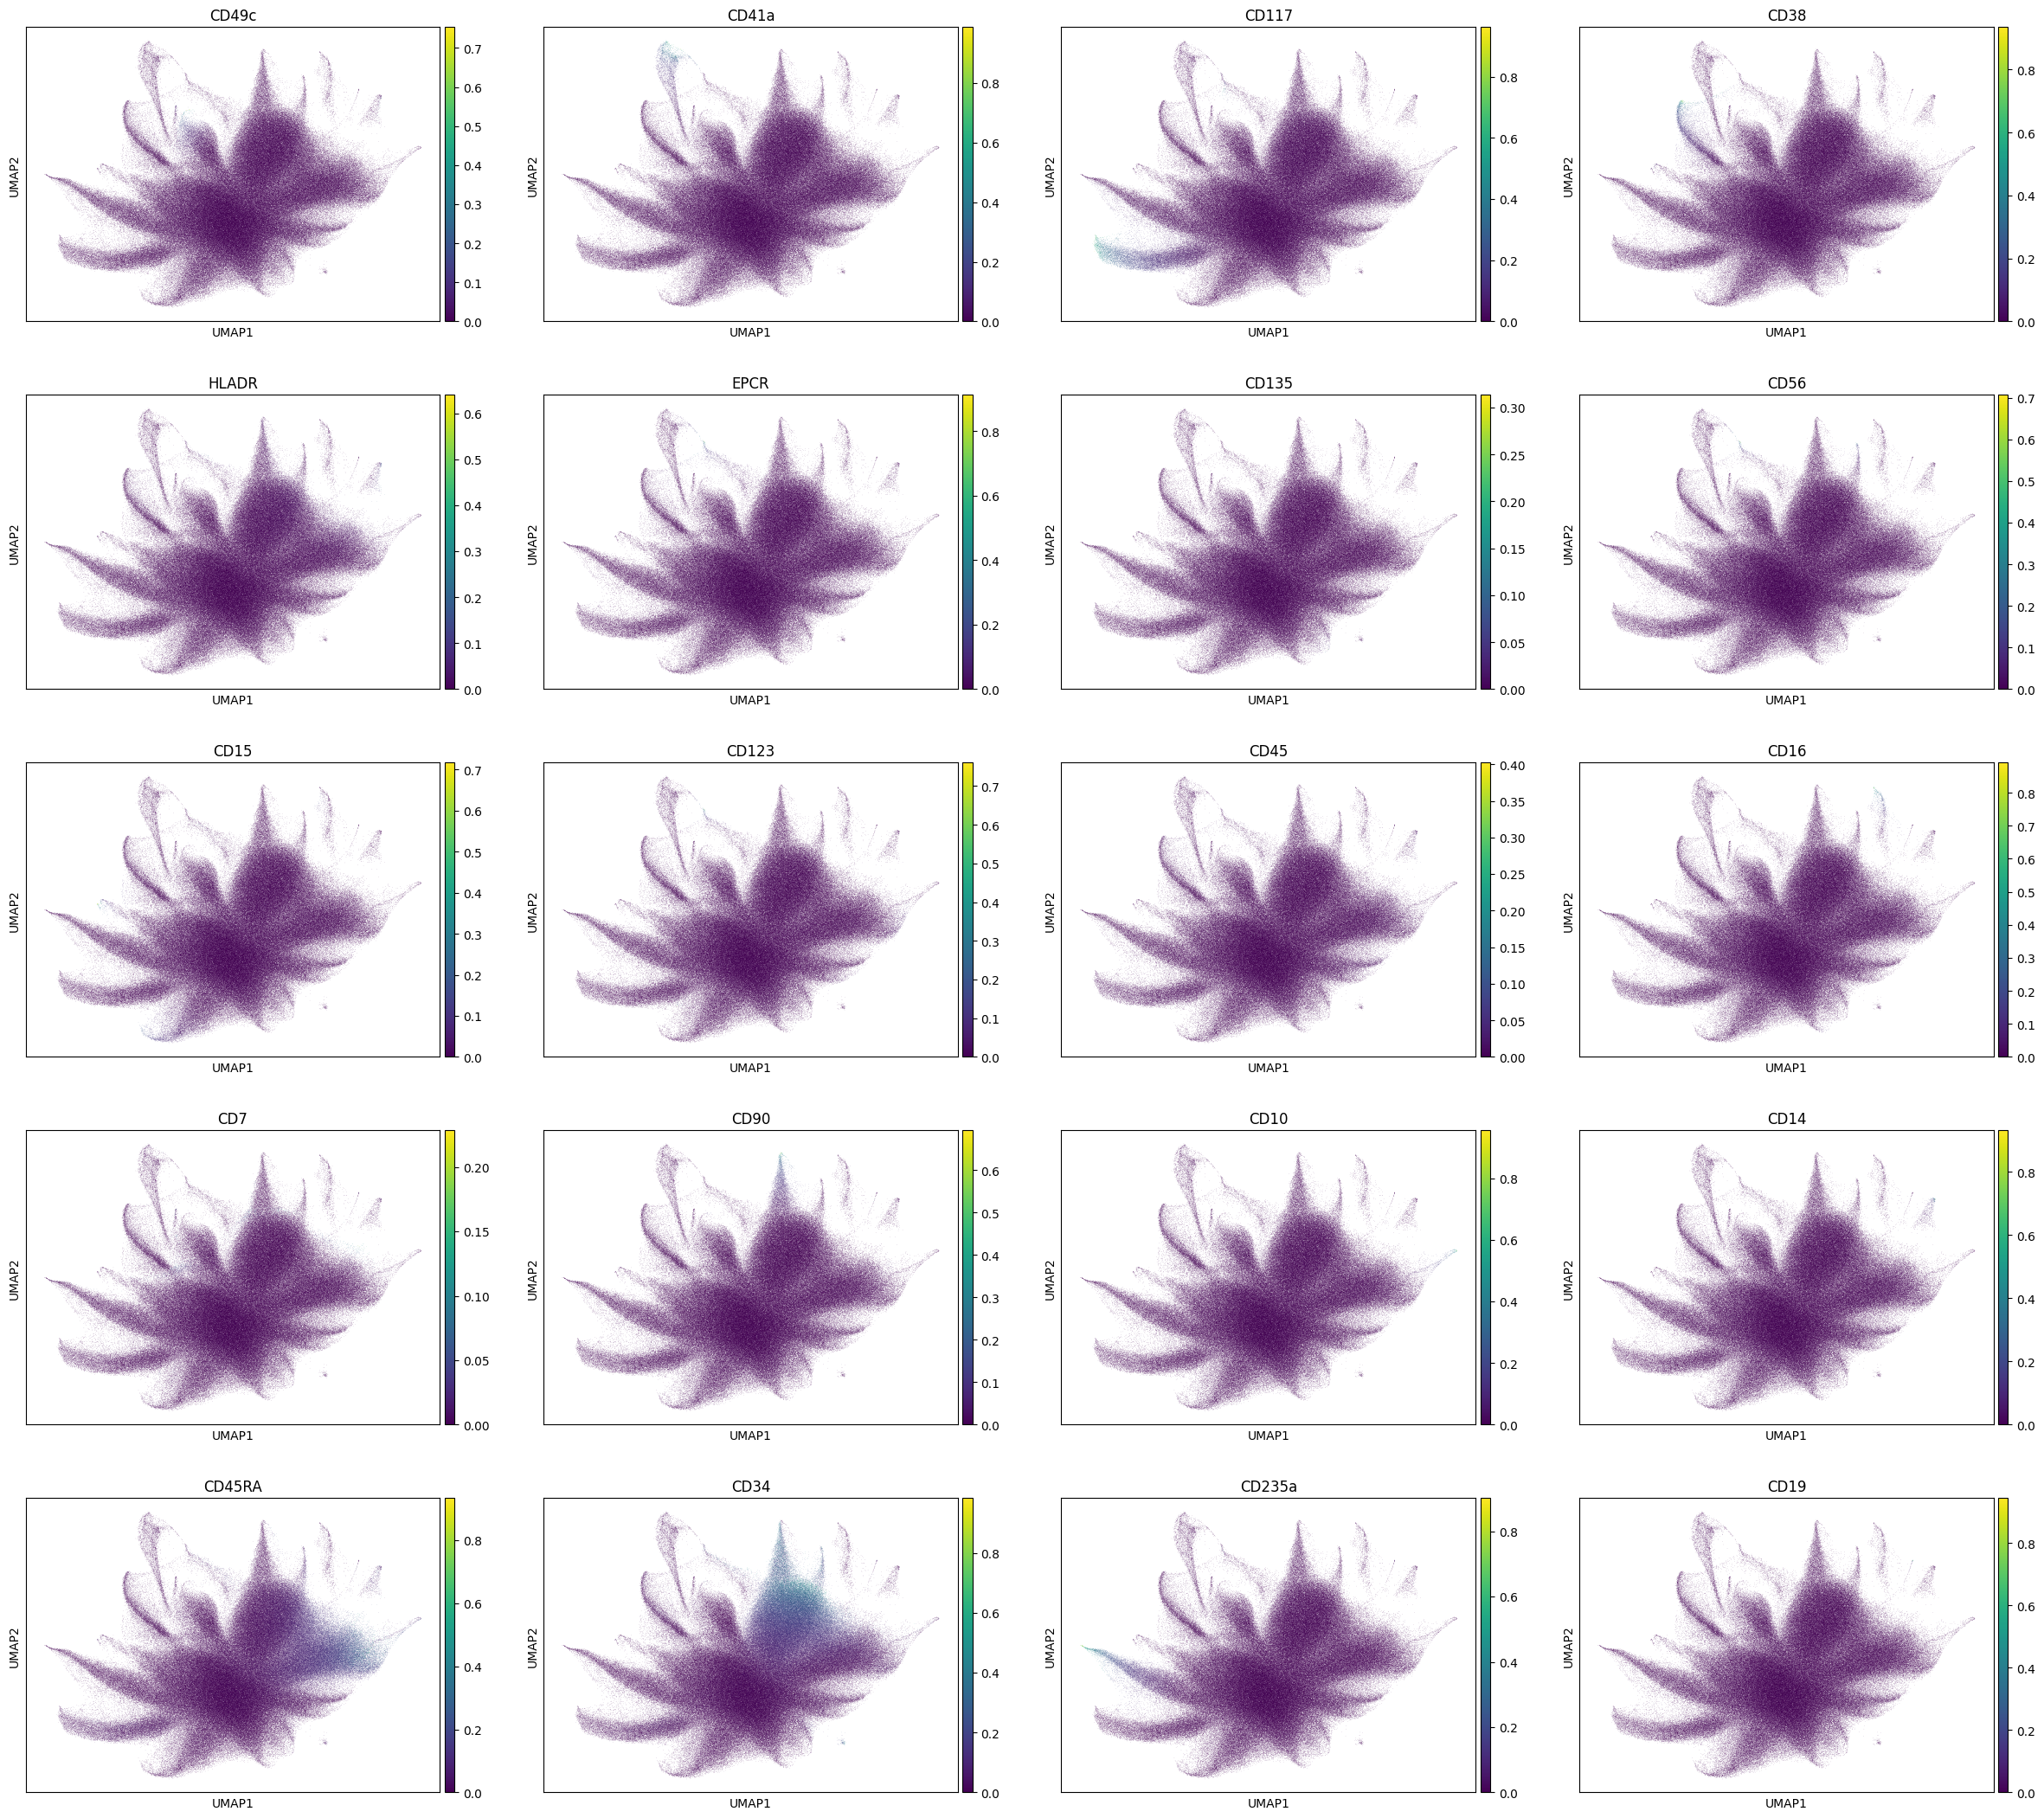

In [4]:
sc.pl.embedding(adata, "umap", color=adata.var_names)

### Plotting over protocol columns.

In [ ]:
# retrieving umap coordinates
X_umap = adata.obsm["X_umap"]

# iterating over protocol columns
for col in PROTOCOL_COLS + ["cell_type"]:

    # retrieving unique values
    unique_vals = adata.obs[col].unique()

    # skipping column with only one value
    if len(unique_vals) == 1:
        print(f"Skipping {col} with only one unique val {unique_vals}.")
        continue

    # defining figure
    fig, ax = plt.subplots(1, len(unique_vals), figsize=(5*len(unique_vals), 5))
    fig.suptitle(f"{col}")

    # iterating over each unique value
    for idx, val in enumerate(unique_vals):

        # retrieving current axes
        cur_ax = ax[idx]

        # computing mask
        val_mask = adata.obs[col] == val

        # plotting base coords
        cur_ax.set_title(f"{idx}:{val}")
        cur_ax.scatter(
            X_umap[:, 0],
            X_umap[:, 1],
            c='lightgrey',  # background cells
            s=20,           # smaller size
            alpha=0.5
        )
        cur_ax.scatter(
            X_umap[val_mask, 0],
            X_umap[val_mask, 1],
            alpha=0.5,
            s=80,
            edgecolor='k',
        )


Skipping 740-yp_[µm] with only one unique val [5].
Skipping mtg_[µm] with only one unique val [100].
Skipping rhflt3l_[ng_ml] with only one unique val [10].


### Plotting for each protocol.

In [ ]:
protocol_obs_key_added = "protocol_id"
protocol_sep = "+"
adata.obs[protocol_obs_key_added] = adata.obs[PROTOCOL_COLS].astype(str).apply(lambda x: protocol_sep.join(x), axis=1)

for idx, unique_val in enumerate(adata.obs[protocol_obs_key_added].unique()):
    # defining figure
    fig, ax = plt.subplots(figsize=(5, 5))

    # computing mask
    val_mask = adata.obs[protocol_obs_key_added] == unique_val

    # plotting base coords
    ax.set_title(f"{idx}:{unique_val}")
    ax.scatter(
        X_umap[:, 0],
        X_umap[:, 1],
        c='lightgrey',  # background cells
        s=20,           # smaller size
        alpha=0.5
    )
    ax.scatter(
        X_umap[val_mask, 0],
        X_umap[val_mask, 1],
        alpha=0.5,
        s=80,
        edgecolor='k',
    )
